In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

In [2]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk import pos_tag

In [3]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [4]:
from gensim.models import Word2Vec

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Embedding
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

In [7]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/chyavanshenoy/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/chyavanshenoy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/chyavanshenoy/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/chyavanshenoy/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [8]:
np.random.seed(1)

In [9]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

In [10]:
print(f"Training set size: {train_df.shape}")
print(f"Testing set size: {test_df.shape}")
print("Categories:", train_df['Category'].unique())

Training set size: (1490, 3)
Testing set size: (735, 2)
Categories: ['business' 'tech' 'politics' 'sport' 'entertainment']


In [11]:
print("Articles per category:")
print(train_df['Category'].value_counts())

Articles per category:
Category
sport            346
business         336
politics         274
entertainment    273
tech             261
Name: count, dtype: int64


In [12]:
print("Sample article from each category:")
for category in train_df['Category'].unique():
    print(f"\nCategory: {category}")
    print(train_df[train_df['Category'] == category]['Text'].sample(1).values[0][:500], "...\n")

Sample article from each category:

Category: business
uk economy facing  major risks  the uk manufacturing sector will continue to face  serious challenges  over the next two years  the british chamber of commerce (bcc) has said.  the group s quarterly survey of companies found exports had picked up in the last three months of 2004 to their best levels in eight years. the rise came despite exchange rates being cited as a major concern. however  the bcc found the whole uk economy still faced  major risks  and warned that growth is set to slow. it re ...


Category: tech
us peer-to-peer pirates convicted the first convictions for piracy over peer-to-peer networks have been handed down in the us.  new yorker william trowbridge and texan michael chicoine have pleaded guilty to charges that they infringed copyright by illegally sharing music  movies and software. the two men faced charges following raids in august on suspected pirates by the fbi. the pair face jail terms of up to five year

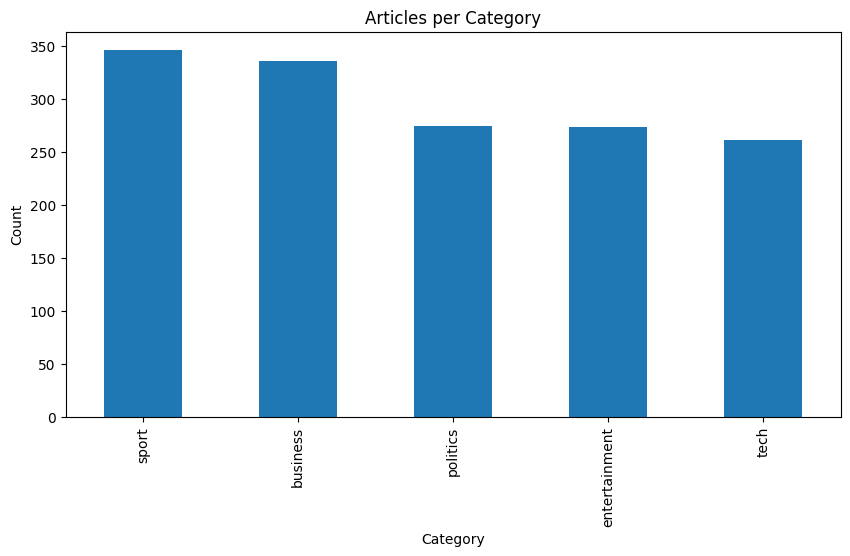

In [13]:
train_df['Category'].value_counts().plot(kind='bar', figsize=(10,5), title="Articles per Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

In [14]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

In [15]:
def basic_preprocessing(text):
    tokens = word_tokenize(text.lower())
    filtered = [w for w in tokens if w.isalpha() and w not in stop_words]
    return ' '.join(filtered)

In [16]:

def advanced_preprocessing(text):
    tokens = word_tokenize(text.lower())
    filtered = [w for w in tokens if w.isalpha() and w not in stop_words]
    lemmatized = [lemmatizer.lemmatize(w) for w in filtered]
    stemmed = [stemmer.stem(w) for w in lemmatized]
    pos_tags = pos_tag(filtered)
    # Keep only nouns, verbs, adjectives, adverbs
    allowed_tags = {'NN', 'NNS', 'NNP', 'NNPS', 'VB', 'VBD', 'VBG', 'VBN', 'VBP', 'VBZ', 'JJ', 'JJR', 'JJS', 'RB', 'RBR', 'RBS'}
    pos_filtered = [stemmer.stem(lemmatizer.lemmatize(w)) for w, tag in pos_tags if tag in allowed_tags]
    return ' '.join(pos_filtered)

In [17]:
start_time = time.time()
train_df['basic_text'] = train_df['Text'].apply(basic_preprocessing)
basic_time = time.time() - start_time

In [18]:
start_time = time.time()
train_df['advanced_text'] = train_df['Text'].apply(advanced_preprocessing)
advanced_time = time.time() - start_time

In [19]:
print(f"Basic preprocessing time: {basic_time:.2f} seconds")
print(f"Advanced preprocessing time: {advanced_time:.2f} seconds")

Basic preprocessing time: 0.92 seconds
Advanced preprocessing time: 9.44 seconds


In [20]:
basic_vocab = set(word for doc in train_df['basic_text'] for word in doc.split())
advanced_vocab = set(word for doc in train_df['advanced_text'] for word in doc.split())

In [21]:
print(f"Vocabulary size (basic): {len(basic_vocab)}")
print(f"Vocabulary size (advanced): {len(advanced_vocab)}")

Vocabulary size (basic): 22996
Vocabulary size (advanced): 15545


In [22]:
count_vectorizer = CountVectorizer()
X_bow = count_vectorizer.fit_transform(train_df['advanced_text'])
print("BoW shape:", X_bow.shape)

BoW shape: (1490, 15525)


In [23]:
tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(train_df['advanced_text'])
print("TF-IDF shape:", X_tfidf.shape)

TF-IDF shape: (1490, 15525)


In [24]:
sentences = [word_tokenize(doc) for doc in train_df['advanced_text']]
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=4)

In [25]:
def get_doc_vector(doc):
    words = word_tokenize(doc)
    vectors = [w2v_model.wv[word] for word in words if word in w2v_model.wv]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(100)


In [26]:
X_w2v = np.array([get_doc_vector(doc) for doc in train_df['advanced_text']])
print("Word2Vec shape:", X_w2v.shape)

Word2Vec shape: (1490, 100)


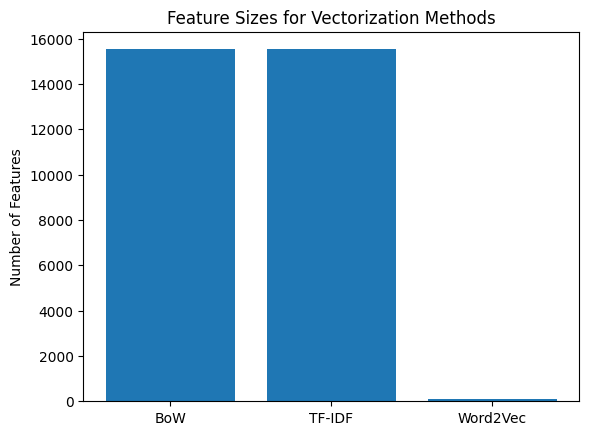

In [27]:
plt.bar(['BoW', 'TF-IDF', 'Word2Vec'], [X_bow.shape[1], X_tfidf.shape[1], X_w2v.shape[1]])
plt.title('Feature Sizes for Vectorization Methods')
plt.ylabel('Number of Features')
plt.show()

In [28]:
y = train_df['Category']

In [29]:
X_train_bow, X_test_bow, y_train, y_test = train_test_split(X_bow, y, test_size=0.2, random_state=1)
X_train_tfidf, X_test_tfidf, _, _ = train_test_split(X_tfidf, y, test_size=0.2, random_state=1)
X_train_w2v, X_test_w2v, _, _ = train_test_split(X_w2v, y, test_size=0.2, random_state=1)

In [30]:
def evaluate_model(model, X_test, y_test, name="Model"):
    y_pred = model.predict(X_test)
    print(f"=== {name} ===")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, average='weighted'))
    print("Recall:", recall_score(y_test, y_pred, average='weighted'))
    print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
    print()

In [31]:
models = []

In [32]:
for X_train, X_test, label in zip([X_train_bow, X_train_tfidf, X_train_w2v],
                                  [X_test_bow, X_test_tfidf, X_test_w2v],
                                  ['BoW', 'TF-IDF', 'Word2Vec']):
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    evaluate_model(model, X_test, y_test, f"Logistic Regression ({label})")
    models.append(model)

=== Logistic Regression (BoW) ===
Accuracy: 0.9798657718120806
Precision: 0.9800723629526071
Recall: 0.9798657718120806
F1 Score: 0.9798633048287833

=== Logistic Regression (TF-IDF) ===
Accuracy: 0.9832214765100671
Precision: 0.9832708251085669
Recall: 0.9832214765100671
F1 Score: 0.9832185119051692

=== Logistic Regression (Word2Vec) ===
Accuracy: 0.9060402684563759
Precision: 0.9070224071997911
Recall: 0.9060402684563759
F1 Score: 0.9059307338100265



In [33]:
texts = train_df['advanced_text'].values
labels = train_df['Category'].values

In [34]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)

In [35]:
max_len = 100
X = pad_sequences(sequences, maxlen=max_len)

In [36]:
print("Shape of input data:", X.shape)
print("Vocabulary size:", len(tokenizer.word_index) + 1)

Shape of input data: (1490, 100)
Vocabulary size: 15546


In [37]:
from sklearn.preprocessing import LabelEncoder

In [38]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(labels)

In [39]:
print("Categories:", label_encoder.classes_)
print("First 10 labels:", y[:10])

Categories: ['business' 'entertainment' 'politics' 'sport' 'tech']
First 10 labels: [0 0 0 4 0 2 3 1 0 1]


In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [41]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1192, 100)
Test shape: (298, 100)


In [42]:
vocab_size = len(tokenizer.word_index) + 1
num_classes = len(label_encoder.classes_)

In [43]:
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(num_classes, activation='softmax')
])

/Users/chyavanshenoy/Desktop/Uni/AAI-520/.venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
2025-09-08 19:31:48.361333: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Max
2025-09-08 19:31:48.361366: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 128.00 GB
2025-09-08 19:31:48.361372: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 48.00 GB
I0000 00:00:1757340108.361729  486254 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1757340108.361772  486254 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [44]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [45]:
# history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

In [46]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2, callbacks=[early_stop], verbose=1)


Epoch 1/10


2025-09-08 19:31:48.845837: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


30/30 ━━━━━━━━━━━━━━━━━━━━ 1235s 42s/step - accuracy: 0.3452 - loss: 1.5857 - val_accuracy: 0.4393 - val_loss: 1.4659
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1217s 42s/step - accuracy: 0.5142 - loss: 1.2494 - val_accuracy: 0.6527 - val_loss: 1.1576
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1092s 37s/step - accuracy: 0.6967 - loss: 0.9262 - val_accuracy: 0.7615 - val_loss: 0.7087
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 305s 10s/step - accuracy: 0.8059 - loss: 0.5848 - val_accuracy: 0.7322 - val_loss: 0.6501
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 304s 10s/step - accuracy: 0.8835 - loss: 0.4398 - val_accuracy: 0.8703 - val_loss: 0.4416
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 435s 15s/step - accuracy: 0.9402 - loss: 0.2492 - val_accuracy: 0.8619 - val_loss: 0.4333
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 446s 15s/step - accuracy: 0.9748 - loss: 0.1370 - val_accuracy: 0.9163 - val_loss: 0.3319
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 457s 15s/step - accuracy: 0.9832 - loss: 0.1307 - val_accuracy: 0.8577 - v

In [47]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.8993


In [48]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 366ms/step


In [49]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Classification Report:
               precision    recall  f1-score   support

     business       0.91      0.90      0.90        68
entertainment       0.93      0.78      0.85        55
     politics       0.85      0.94      0.89        53
        sport       0.94      0.97      0.96        67
         tech       0.86      0.89      0.88        55

     accuracy                           0.90       298
    macro avg       0.90      0.90      0.90       298
 weighted avg       0.90      0.90      0.90       298



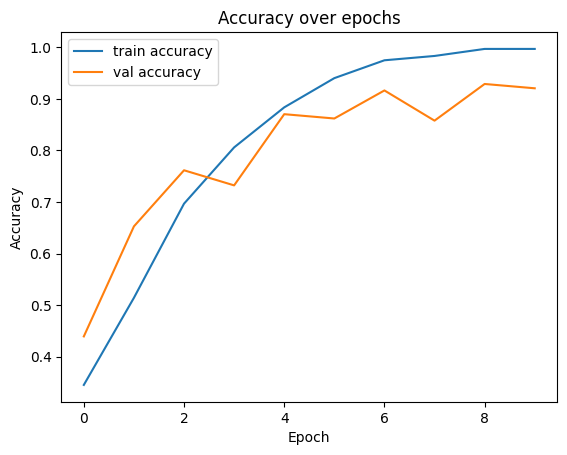

In [50]:
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

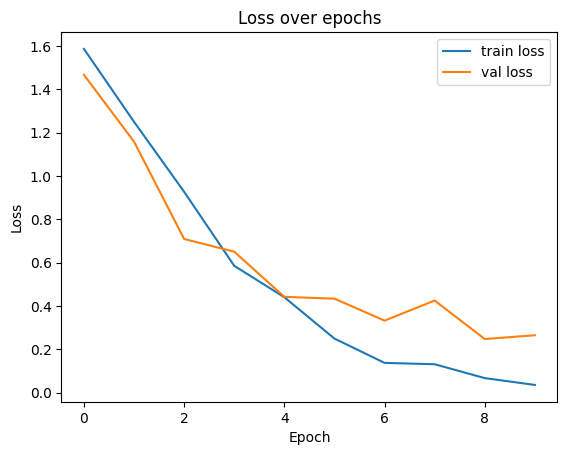

In [51]:

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [57]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(train_df['Category'].values)
num_classes = len(label_encoder.classes_)

In [58]:
texts = train_df['advanced_text'].values
tokenizer = Tokenizer()
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
max_len = 100
X = pad_sequences(sequences, maxlen=max_len)
vocab_size = len(tokenizer.word_index) + 1

In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)


In [62]:
def build_and_train_lstm(X_train, X_test, y_train, y_test, name="LSTM Model"):
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len),
        LSTM(64, dropout=0.2, recurrent_dropout=0.2),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
    history = model.fit(X_train, y_train, epochs=10, batch_size=128, validation_split=0.2, callbacks=[early_stop], verbose=1)
    
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(f"{name} Test Accuracy: {accuracy:.4f}")
    
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    print(f"=== {name} Classification Report ===")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))
    
    return model, history

In [63]:
# Training LSTM for Bag of Words
lstm_bow_model, history_bow = build_and_train_lstm(X_train, X_test, y_train, y_test, name="LSTM (BoW)")

Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 84s 10s/step - accuracy: 0.2613 - loss: 1.6047 - val_accuracy: 0.2427 - val_loss: 1.5951
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 83s 10s/step - accuracy: 0.3820 - loss: 1.5600 - val_accuracy: 0.2929 - val_loss: 1.5557
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 83s 10s/step - accuracy: 0.4711 - loss: 1.4079 - val_accuracy: 0.6402 - val_loss: 1.2708
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 82s 10s/step - accuracy: 0.7471 - loss: 1.0298 - val_accuracy: 0.8577 - val_loss: 0.8539
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 82s 10s/step - accuracy: 0.7733 - loss: 0.8060 - val_accuracy: 0.8494 - val_loss: 0.7823
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 82s 10s/step - accuracy: 0.8206 - loss: 0.7272 - val_accuracy: 0.8326 - val_loss: 0.7150
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 84s 11s/step - accuracy: 0.9119 - loss: 0.5214 - val_accuracy: 0.8996 - val_loss: 0.5102
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 82s 10s/step - accuracy: 0.9412 - loss: 0.3626 - val_accuracy: 0.9414 - val_loss: 0.3446


In [64]:
# Training LSTM for TF-IDF
lstm_tfidf_model, history_tfidf = build_and_train_lstm(X_train, X_test, y_train, y_test, name="LSTM (TF-IDF)")

Epoch 1/10


/Users/chyavanshenoy/Desktop/Uni/AAI-520/.venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


8/8 ━━━━━━━━━━━━━━━━━━━━ 84s 10s/step - accuracy: 0.3085 - loss: 1.6026 - val_accuracy: 0.3431 - val_loss: 1.5896
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 82s 10s/step - accuracy: 0.3788 - loss: 1.5508 - val_accuracy: 0.2803 - val_loss: 1.5291
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 82s 10s/step - accuracy: 0.5414 - loss: 1.3584 - val_accuracy: 0.6318 - val_loss: 1.2214
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 82s 10s/step - accuracy: 0.6390 - loss: 1.0942 - val_accuracy: 0.5397 - val_loss: 1.0408
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 82s 10s/step - accuracy: 0.7072 - loss: 0.8691 - val_accuracy: 0.7866 - val_loss: 0.7843
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 83s 10s/step - accuracy: 0.8447 - loss: 0.6828 - val_accuracy: 0.7866 - val_loss: 0.6747
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 82s 10s/step - accuracy: 0.8604 - loss: 0.5919 - val_accuracy: 0.8159 - val_loss: 0.6455
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 83s 10s/step - accuracy: 0.9265 - loss: 0.4536 - val_accuracy: 0.8577 - val_loss: 0.5079
Epoch 9/10


In [65]:
# Training LSTM for Word2Vec
lstm_w2v_model, history_w2v = build_and_train_lstm(X_train, X_test, y_train, y_test, name="LSTM (Word2Vec)")

Epoch 1/10


/Users/chyavanshenoy/Desktop/Uni/AAI-520/.venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


8/8 ━━━━━━━━━━━━━━━━━━━━ 83s 10s/step - accuracy: 0.2749 - loss: 1.6046 - val_accuracy: 0.3724 - val_loss: 1.5932
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 81s 10s/step - accuracy: 0.4218 - loss: 1.5601 - val_accuracy: 0.3013 - val_loss: 1.5395
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 82s 10s/step - accuracy: 0.4837 - loss: 1.3882 - val_accuracy: 0.6653 - val_loss: 1.2512
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 81s 10s/step - accuracy: 0.7167 - loss: 1.0844 - val_accuracy: 0.6987 - val_loss: 0.8934
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 82s 10s/step - accuracy: 0.7629 - loss: 0.8476 - val_accuracy: 0.7238 - val_loss: 0.7801
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 82s 10s/step - accuracy: 0.8646 - loss: 0.7078 - val_accuracy: 0.8410 - val_loss: 0.6992
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 82s 10s/step - accuracy: 0.8951 - loss: 0.6309 - val_accuracy: 0.8452 - val_loss: 0.6247
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 83s 10s/step - accuracy: 0.9276 - loss: 0.5082 - val_accuracy: 0.8326 - val_loss: 0.5784
Epoch 9/10


In [66]:
def evaluate_lstm_model(model, X_test, y_test, name="LSTM Model"):
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    print(f"\n=== {name} Evaluation ===")
    print(f"Test Accuracy: {accuracy:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


In [67]:
evaluate_lstm_model(lstm_bow_model, X_test, y_test, "LSTM (BoW)")

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 292ms/step

=== LSTM (BoW) Evaluation ===
Test Accuracy: 0.9161
Classification Report:
               precision    recall  f1-score   support

     business       0.95      0.79      0.86        68
entertainment       0.83      0.96      0.89        55
     politics       0.88      0.96      0.92        53
        sport       0.97      1.00      0.99        67
         tech       0.96      0.87      0.91        55

     accuracy                           0.92       298
    macro avg       0.92      0.92      0.91       298
 weighted avg       0.92      0.92      0.92       298



In [68]:
evaluate_lstm_model(lstm_tfidf_model, X_test, y_test, "LSTM (TF-IDF)")

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 293ms/step

=== LSTM (TF-IDF) Evaluation ===
Test Accuracy: 0.9195
Classification Report:
               precision    recall  f1-score   support

     business       0.92      0.90      0.91        68
entertainment       0.92      0.85      0.89        55
     politics       0.88      0.96      0.92        53
        sport       0.99      1.00      0.99        67
         tech       0.87      0.87      0.87        55

     accuracy                           0.92       298
    macro avg       0.92      0.92      0.92       298
 weighted avg       0.92      0.92      0.92       298



In [69]:
evaluate_lstm_model(lstm_w2v_model, X_test, y_test, "LSTM (Word2Vec)")

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 300ms/step

=== LSTM (Word2Vec) Evaluation ===
Test Accuracy: 0.8792
Classification Report:
               precision    recall  f1-score   support

     business       0.98      0.79      0.88        68
entertainment       0.92      0.87      0.90        55
     politics       0.78      0.92      0.84        53
        sport       0.96      0.99      0.97        67
         tech       0.76      0.82      0.79        55

     accuracy                           0.88       298
    macro avg       0.88      0.88      0.88       298
 weighted avg       0.89      0.88      0.88       298



In [70]:
def plot_history(history, name="Model"):
    # Accuracy plot
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{name} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

    # Loss plot
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{name} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

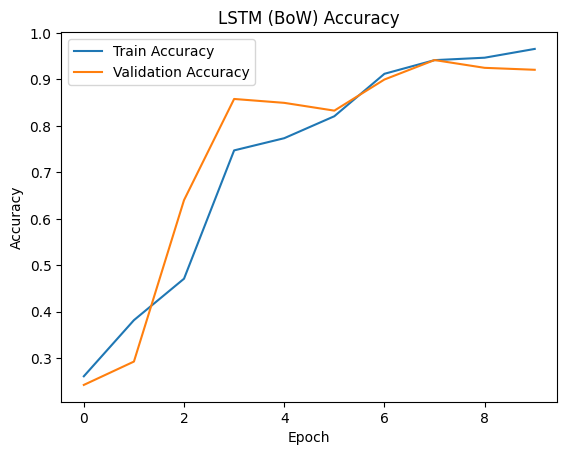

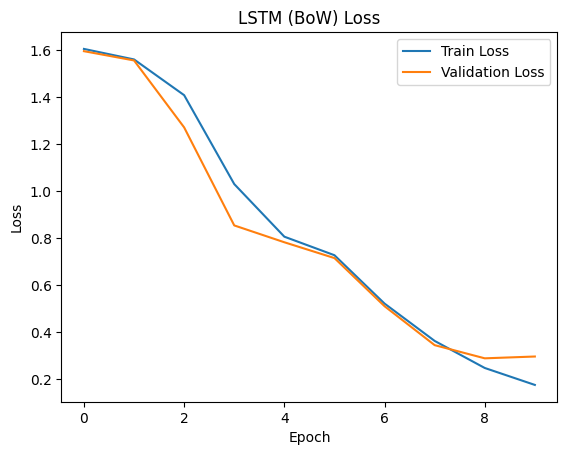

In [71]:
plot_history(history_bow, "LSTM (BoW)")

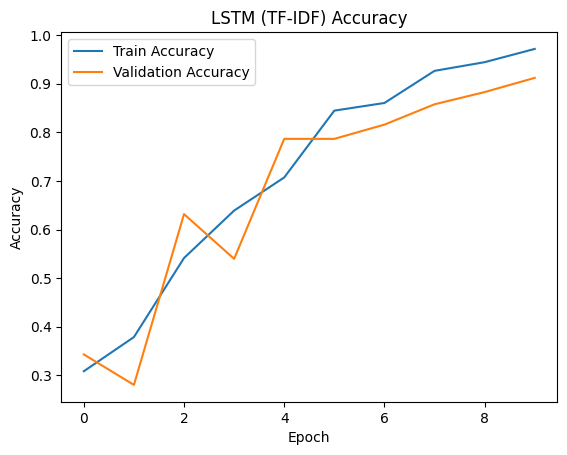

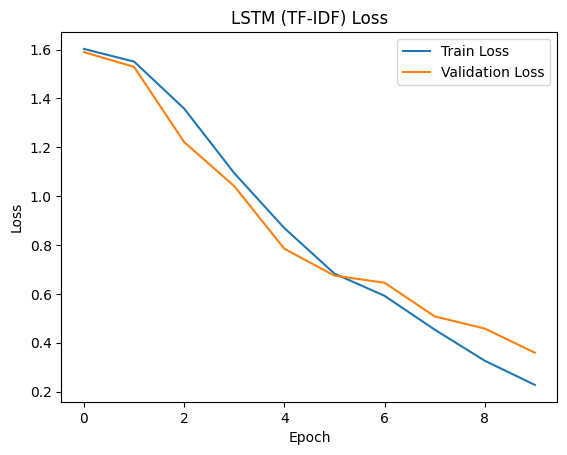

In [72]:
plot_history(history_tfidf, "LSTM (TF-IDF)")

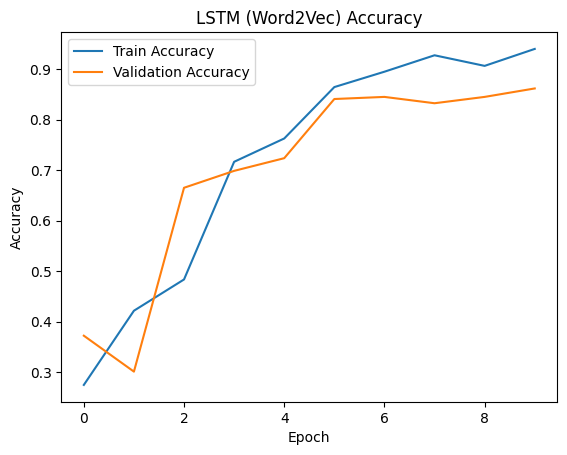

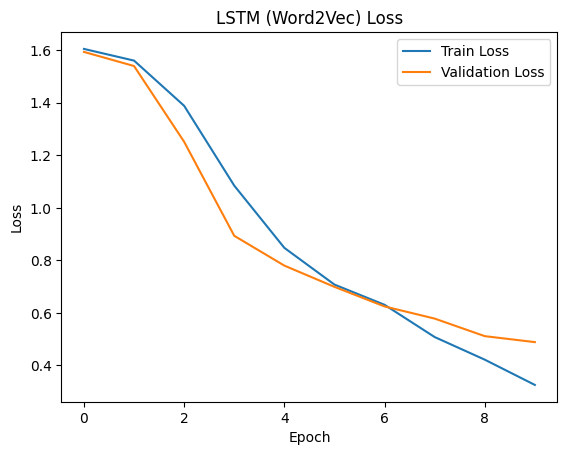

In [73]:
plot_history(history_w2v, "LSTM (Word2Vec)")

In [74]:
def get_metrics(model, X_test, y_test, name="Model"):
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    y_pred = np.argmax(model.predict(X_test), axis=1)
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1-Score": f1_score(y_test, y_pred, average='weighted')
    }

In [75]:
results = [
    get_metrics(lstm_bow_model, X_test, y_test, "LSTM (BoW)"),
    get_metrics(lstm_tfidf_model, X_test, y_test, "LSTM (TF-IDF)"),
    get_metrics(lstm_w2v_model, X_test, y_test, "LSTM (Word2Vec)")
]

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 296ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 389ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 394ms/step


In [76]:
results_df = pd.DataFrame(results)
print(results_df)

             Model  Accuracy  Precision    Recall  F1-Score
0       LSTM (BoW)  0.916107   0.920904  0.916107  0.915257
1    LSTM (TF-IDF)  0.919463   0.919976  0.919463  0.919095
2  LSTM (Word2Vec)  0.879195   0.888561  0.879195  0.880132


## AI Use Disclosure

- I have made use of Gemini to Verify the completeness of the notebook in regards to the rubrics.
- Chat URL: https://gemini.google.com/app/5bd39f447612bfea